In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Notebook display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.1f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded!!!')

Libraries loaded!!!


In [8]:
np.random.seed(42)
N = 500

# ----------- Age (35-85), slightly right skew via gamma -----------------
# NumPy's gamma has no loc; shift after sampling. Use size=N for one draw per patient.
age = np.clip(np.random.gamma(shape=6, scale=8, size=N) + 32, 35, 85).astype(int)

# -------------- Systolic BP (base normal + hypertensive outlier cluster) ------------
bp_base = np.random.normal(loc=130, scale=18, size=N)
bp_outlier = np.random.normal(loc=185, scale=8, size=30)
bp_systolic = np.clip(
    np.concatenate([bp_base[:470], bp_outlier]),
    90, 200
).astype(int)
np.random.shuffle(bp_systolic)

# --- LDL Cholesterol (roughly normal, clinically plausible) ---
cholesterol_ldl = np.clip(
    np.random.normal(loc=130, scale=35, size=N),
    60, 250
).astype(int)

# --- Blood Glucose (right-skewed — diabetic tail) ---
glucose_base     = np.random.normal(loc=95, scale=18, size=N)
glucose_diabetic = np.random.normal(loc=280, scale=60, size=60)  # 60 diabetic pts
blood_glucose = np.clip(
    np.concatenate([glucose_base[:440], glucose_diabetic]),
    70, 400
).astype(int)
np.random.shuffle(blood_glucose)


# --- Hospital Stay Days (heavily right-skewed — most short, few very long) ---
hospital_stay = np.clip(
    np.random.exponential(scale=4, size=N),
    1, 30
).astype(int)


# --- 30-Day Readmission (binary, ~22% positive rate) ---
# Correlated with longer stay + higher glucose
readmit_prob = 1 / (1 + np.exp(-(
    -2.5
    + 0.04 * hospital_stay
    + 0.008 * blood_glucose
    + 0.01 * age
)))
readmitted = (np.random.random(N) < readmit_prob).astype(int)

df = pd.DataFrame({
    'Patient_ID'           : [f'P{str(i).zfill(3)}' for i in range(1, N+1)],
    'Age'                  : age,
    'BP_Systolic'          : bp_systolic,
    'Cholesterol_LDL'      : cholesterol_ldl,
    'Blood_Glucose'        : blood_glucose,
    'Hospital_Stay_Days'   : hospital_stay,
    'Readmitted_30_Days'   : readmitted,
})


print(f"Dataset created: {df.shape[0]} patients × {df.shape[1]} columns")
print(f"Readmission rate: {df['Readmitted_30_Days'].mean():.1%}")
df.head(8)

Dataset created: 500 patients × 7 columns
Readmission rate: 34.4%


,Patient_ID,Age,BP_Systolic,Cholesterol_LDL,Blood_Glucose,Hospital_Stay_Days,Readmitted_30_Days
0,P001,85,171,150,371,1,1
1,P002,74,180,141,70,3,0
2,P003,73,116,136,77,5,0
3,P004,73,129,117,86,1,0
4,P005,85,162,141,94,4,1
5,P006,85,134,119,107,3,1
6,P007,68,136,135,70,1,1
7,P008,85,115,176,162,1,0


In [13]:
df.describe().round(1)

,Age,BP_Systolic,Cholesterol_LDL,Blood_Glucose,Hospital_Stay_Days,Readmitted_30_Days
count,500.0,500.0,500.0,500.0,500.0,500.0
mean,74.2,134.8,129.9,118.4,3.5,0.3
std,11.0,21.6,32.7,66.6,3.6,0.5
min,39.0,90.0,60.0,70.0,1.0,0.0
25%,66.0,120.0,108.0,84.0,1.0,0.0
50%,77.0,133.0,129.5,99.0,2.0,0.0
75%,85.0,146.0,152.0,113.0,4.0,1.0
max,85.0,200.0,239.0,400.0,24.0,1.0


In [15]:

#Run those three cells in order and you're set. A couple of things worth knowing about the design of this dataset:
#The readmission column isn't purely random — it's generated using a logistic function that gives higher readmission probability to patients with longer stays, higher glucose, and older age. That's intentional: when we get to correlation in Topic 8, you'll actually be able to detect those relationships in the data, just like a real ML pipeline would.
#The glucose and blood pressure columns have deliberate outlier clusters baked in — 60 "diabetic" patients with very high glucose, and 30 "hypertensive" patients with very high BP. These will become very visible when we plot histograms and boxplots in Topics 6 and 7, and they'll give us real, meaningful outliers to reason about rather than contrived ones.

![Central tendency](../img/central_tendency.png)

In [16]:
from scipy import stats

col = 'Blood_Glucose'

# --------------------- Compute the three measures -------------
mean_val = df[col].mean()
median_val = df[col].median()
mode_val = df[col].mode()[0] # .mode() returns a Series; [0] = most frequent


print(f"Blood Glucose — Central Tendency")
print(f"{'─'*38}")
print(f"  Mean   (x̄) : {mean_val:.1f} mg/dL")
print(f"  Median (M)  : {median_val:.1f} mg/dL")
print(f"  Mode        : {mode_val:.1f} mg/dL")
print(f"{'─'*38}")
print(f"  Mean − Median gap: {mean_val - median_val:.1f} mg/dL")
print(f"  ↑ Positive gap signals RIGHT SKEW (outliers pulling mean up)")

Blood Glucose — Central Tendency
──────────────────────────────────────
  Mean   (x̄) : 118.4 mg/dL
  Median (M)  : 99.0 mg/dL
  Mode        : 70.0 mg/dL
──────────────────────────────────────
  Mean − Median gap: 19.4 mg/dL
  ↑ Positive gap signals RIGHT SKEW (outliers pulling mean up)


In [17]:
# Compare with Cholesterol LDL — more symmetrically distributed
col2 = 'Cholesterol_LDL'

mean2   = df[col2].mean()
median2 = df[col2].median()
mode2   = df[col2].mode()[0]

print(f"Cholesterol LDL — Central Tendency")
print(f"{'─'*38}")
print(f"  Mean   (x̄) : {mean2:.1f} mg/dL")
print(f"  Median (M)  : {median2:.1f} mg/dL")
print(f"  Mode        : {mode2:.1f} mg/dL")
print(f"{'─'*38}")
print(f"  Mean − Median gap: {mean2 - median2:.1f} mg/dL")
print(f"  ↑ Near-zero gap signals SYMMETRY (mean ≈ median ≈ mode)")

Cholesterol LDL — Central Tendency
──────────────────────────────────────
  Mean   (x̄) : 129.9 mg/dL
  Median (M)  : 129.5 mg/dL
  Mode        : 60.0 mg/dL
──────────────────────────────────────
  Mean − Median gap: 0.4 mg/dL
  ↑ Near-zero gap signals SYMMETRY (mean ≈ median ≈ mode)


⚠️ Common Pitfall: Many beginners default to the mean for everything. But when your data has outliers or is skewed (like hospital stay days, income, or our glucose column), the mean can be deeply misleading. Always compute both mean and median first — a large gap between them is your warning signal to investigate further.

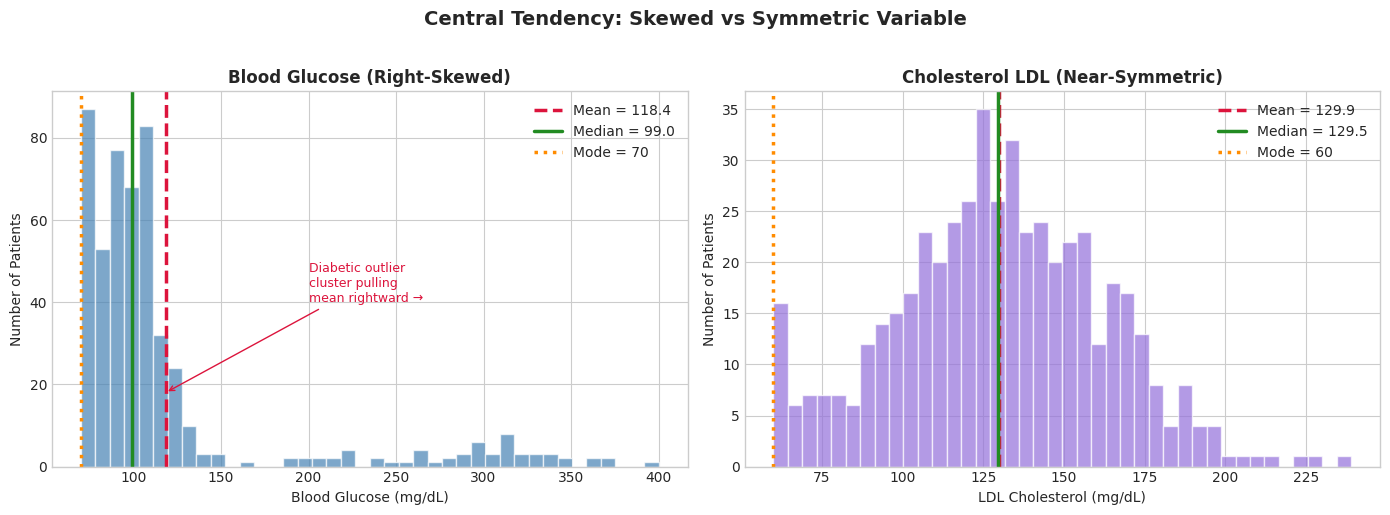

Chart saved as central_tendency.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Central Tendency: Skewed vs Symmetric Variable', 
             fontsize=14, fontweight='bold', y=1.02)

# ── Left plot: Blood Glucose (skewed) ──────────────────────────────
ax1 = axes[0]
ax1.hist(df['Blood_Glucose'], bins=40, color='steelblue', 
         alpha=0.7, edgecolor='white')

mean_g   = df['Blood_Glucose'].mean()
median_g = df['Blood_Glucose'].median()
mode_g   = df['Blood_Glucose'].mode()[0]

ax1.axvline(mean_g,   color='crimson',     linewidth=2.5, 
            linestyle='--', label=f'Mean = {mean_g:.1f}')
ax1.axvline(median_g, color='forestgreen', linewidth=2.5, 
            linestyle='-',  label=f'Median = {median_g:.1f}')
ax1.axvline(mode_g,   color='darkorange',  linewidth=2.5, 
            linestyle=':',  label=f'Mode = {mode_g:.0f}')

ax1.set_title('Blood Glucose (Right-Skewed)', fontweight='bold')
ax1.set_xlabel('Blood Glucose (mg/dL)')
ax1.set_ylabel('Number of Patients')
ax1.legend(fontsize=10)
ax1.annotate('Diabetic outlier\ncluster pulling\nmean rightward →',
             xy=(mean_g, 18), xytext=(200, 40),
             arrowprops=dict(arrowstyle='->', color='crimson'),
             fontsize=9, color='crimson')

# ── Right plot: Cholesterol LDL (symmetric) ────────────────────────
ax2 = axes[1]
ax2.hist(df['Cholesterol_LDL'], bins=40, color='mediumpurple', 
         alpha=0.7, edgecolor='white')

mean_c   = df['Cholesterol_LDL'].mean()
median_c = df['Cholesterol_LDL'].median()
mode_c   = df['Cholesterol_LDL'].mode()[0]

ax2.axvline(mean_c,   color='crimson',     linewidth=2.5, 
            linestyle='--', label=f'Mean = {mean_c:.1f}')
ax2.axvline(median_c, color='forestgreen', linewidth=2.5, 
            linestyle='-',  label=f'Median = {median_c:.1f}')
ax2.axvline(mode_c,   color='darkorange',  linewidth=2.5, 
            linestyle=':',  label=f'Mode = {mode_c:.0f}')

ax2.set_title('Cholesterol LDL (Near-Symmetric)', fontweight='bold')
ax2.set_xlabel('LDL Cholesterol (mg/dL)')
ax2.set_ylabel('Number of Patients')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('central_tendency.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as central_tendency.png")

# 2. The Medical Analogy — Before Any Math
Imagine two hospital wards, both with a mean systolic BP of 130 mmHg:
`Ward A` — every patient has BP between 125 and 135 mmHg. Tight, stable, predictable. Your nursing team can write one protocol and it covers everyone.
`Ward B` — patients range from 90 to 190 mmHg. Same average, completely different reality. Some patients are in hypotensive shock, others are hypertensive crisis. One protocol covers nobody well.
That spread is what dispersion measures. Now let's meet the three tools that quantify it:

`Range` is the security guard who only checks the front and back of the queue — it only sees the two most extreme patients and ignores everyone in between.
`Variance` is the meticulous registrar who measures every patient's distance from the mean, squares it to avoid negatives cancelling out, and averages those squared distances.
`Standard Deviation` is the *variance* brought back to the original unit — mg/dL, mmHg, days — so it's clinically interpretable again. It's the one you'll use most.

![Measures of Dispersion](../img/dispersion.png)

In [19]:
col = 'BP_Systolic'

# --- Range ---
bp_range = df[col].max() - df[col].min()

# --- Variance (sample) — ddof=1 means divide by n-1 ---
bp_variance = df[col].var(ddof=1)

# --- Standard Deviation (sample) ---
bp_std = df[col].std(ddof=1)

# --- Mean for reference ---
bp_mean = df[col].mean()

print(f"BP Systolic — Measures of Dispersion")
print(f"{'─'*42}")
print(f"  Min              : {df[col].min()} mmHg")
print(f"  Max              : {df[col].max()} mmHg")
print(f"  Range            : {bp_range} mmHg")
print(f"{'─'*42}")
print(f"  Mean (x̄)         : {bp_mean:.1f} mmHg")
print(f"  Variance (s²)    : {bp_variance:.1f} mmHg²")
print(f"  Std Dev (s)      : {bp_std:.1f} mmHg")
print(f"{'─'*42}")
print(f"  Interpretation:")
print(f"  A 'typical' patient is {bp_mean:.1f} ± {bp_std:.1f} mmHg")
print(f"  i.e., roughly {bp_mean-bp_std:.1f} – {bp_mean+bp_std:.1f} mmHg")

BP Systolic — Measures of Dispersion
──────────────────────────────────────────
  Min              : 90 mmHg
  Max              : 200 mmHg
  Range            : 110 mmHg
──────────────────────────────────────────
  Mean (x̄)         : 134.8 mmHg
  Variance (s²)    : 464.6 mmHg²
  Std Dev (s)      : 21.6 mmHg
──────────────────────────────────────────
  Interpretation:
  A 'typical' patient is 134.8 ± 21.6 mmHg
  i.e., roughly 113.2 – 156.3 mmHg


In [20]:
# Walk through variance step-by-step on first 6 patients
# so the formula stops feeling abstract

sample = df['BP_Systolic'].head(6).values
mean_s = sample.mean()

print(f"6-patient sample BPs: {sample}")
print(f"Sample mean: {mean_s:.1f} mmHg\n")
print(f"{'Patient':<10} {'BP':>6} {'Deviation (x-x̄)':>18} {'Deviation²':>12}")
print("─" * 50)

deviations_sq = []
for i, bp in enumerate(sample):
    dev = bp - mean_s
    dev_sq = dev ** 2
    deviations_sq.append(dev_sq)
    print(f"P{i+1:<9} {bp:>6} {dev:>+18.1f} {dev_sq:>12.1f}")

print("─" * 50)
print(f"{'Sum of squared devs:':>36} {sum(deviations_sq):>9.1f}")
print(f"{'Variance (÷ n-1=5):':>36} {sum(deviations_sq)/5:>9.1f}")
print(f"{'Std Dev (√variance):':>36} {(sum(deviations_sq)/5)**0.5:>9.1f}")

6-patient sample BPs: [171 180 116 129 162 134]
Sample mean: 148.7 mmHg

Patient        BP   Deviation (x-x̄)   Deviation²
──────────────────────────────────────────────────
P1            171              +22.3        498.8
P2            180              +31.3        981.8
P3            116              -32.7       1067.1
P4            129              -19.7        386.8
P5            162              +13.3        177.8
P6            134              -14.7        215.1
──────────────────────────────────────────────────
                Sum of squared devs:    3327.3
                 Variance (÷ n-1=5):     665.5
                Std Dev (√variance):      25.8


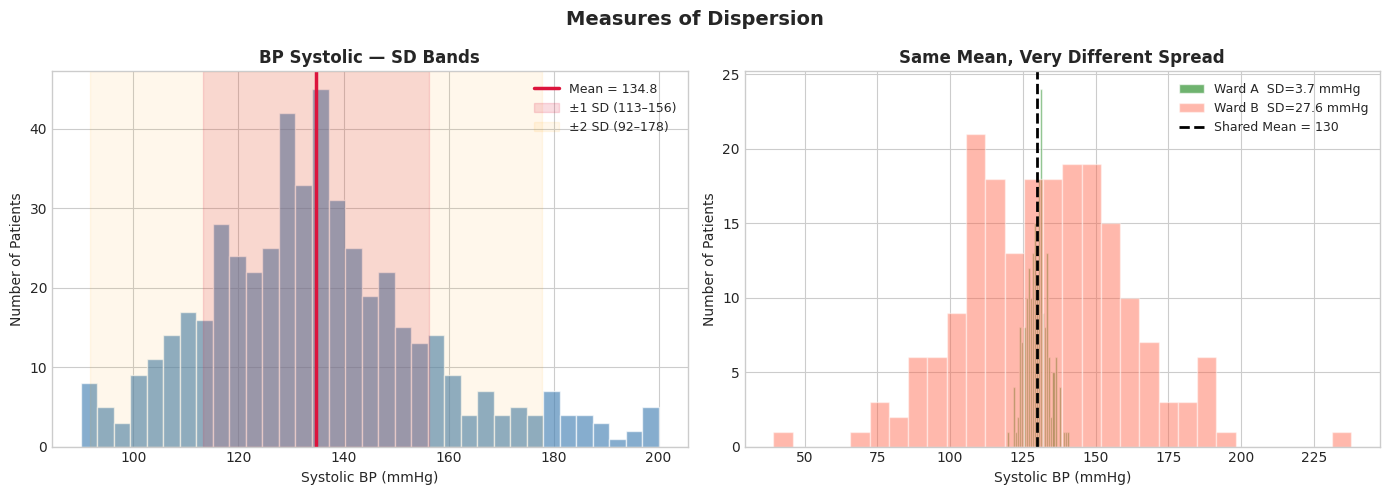

Chart saved as dispersion.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Measures of Dispersion', fontsize=14, fontweight='bold')

# ── Left: BP Systolic with SD bands ───────────────────────────────
ax1 = axes[0]
bp_mean = df['BP_Systolic'].mean()
bp_std  = df['BP_Systolic'].std(ddof=1)

ax1.hist(df['BP_Systolic'], bins=35, color='steelblue',
         alpha=0.65, edgecolor='white')
ax1.axvline(bp_mean, color='crimson', linewidth=2.5,
            label=f'Mean = {bp_mean:.1f}')

# Shade ±1 SD band
ax1.axvspan(bp_mean - bp_std, bp_mean + bp_std,
            alpha=0.15, color='crimson',
            label=f'±1 SD ({bp_mean-bp_std:.0f}–{bp_mean+bp_std:.0f})')

# Shade ±2 SD band
ax1.axvspan(bp_mean - 2*bp_std, bp_mean + 2*bp_std,
            alpha=0.08, color='orange',
            label=f'±2 SD ({bp_mean-2*bp_std:.0f}–{bp_mean+2*bp_std:.0f})')

ax1.set_title('BP Systolic — SD Bands', fontweight='bold')
ax1.set_xlabel('Systolic BP (mmHg)')
ax1.set_ylabel('Number of Patients')
ax1.legend(fontsize=9)

# ── Right: Ward A vs Ward B analogy ───────────────────────────────
ax2 = axes[1]
np.random.seed(42)
ward_a = np.random.normal(loc=130, scale=4,  size=200)  # tight spread
ward_b = np.random.normal(loc=130, scale=28, size=200)  # wide spread

ax2.hist(ward_a, bins=30, alpha=0.65, color='forestgreen',
         label=f'Ward A  SD={ward_a.std():.1f} mmHg', edgecolor='white')
ax2.hist(ward_b, bins=30, alpha=0.45, color='tomato',
         label=f'Ward B  SD={ward_b.std():.1f} mmHg', edgecolor='white')
ax2.axvline(130, color='black', linewidth=2,
            linestyle='--', label='Shared Mean = 130')

ax2.set_title('Same Mean, Very Different Spread', fontweight='bold')
ax2.set_xlabel('Systolic BP (mmHg)')
ax2.set_ylabel('Number of Patients')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('dispersion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as dispersion.png")

`What to look for when your chart renders:`

`Left panel`: The dark red band (±1 SD) captures the bulk of your patients — roughly 68% in a normal distribution. The orange band (±2 SD) sweeps out to cover ~95%. Patients sitting outside the orange band are your statistical outliers — and you can literally see the hypertensive cluster sitting beyond the right edge.

`Right panel`: This is your Ward A vs Ward B analogy made visual. Both histograms are centred on 130 mmHg, but Ward B (red) is so spread out it's nearly flat — patients are distributed from hypotensive to hypertensive crisis. Same mean, completely different clinical reality. If you only reported the mean, you'd miss this entirely.

### 6. Clinical Relevance — Where This Shows Up in ML/DS 1 — Reporting Clinical Trial Variability: Every efficacy table in a randomised controlled trial reports mean ± SD for continuous outcomes. A drug that reduces BP by a mean of 15 mmHg with SD of 3 is dramatically more consistent — and clinically preferable — to one with the same mean reduction but SD of 20, where some patients barely respond and others drop dangerously low.
**Scenario 2 — Feature Scaling Before ML Modelling:** Before feeding data into algorithms like logistic regression, SVMs, or neural networks, you must **standardise** your features using the Z-score formula: z=x−xˉsz = \frac{x - \bar{x}}{s}
z=sx−xˉ​. This literally divides by the standard deviation. If you don't understand what SD means, you can't understand *why* scaling matters or *what* you're destroying if you do it incorrectly.
Scenario 3 — Anomaly Detection / Flagging High-Risk Patients: A common clinical decision rule is to flag any patient whose value is more than 2 SD from the mean as an outlier warranting review. This is the statistical backbone of laboratory reference ranges — when a lab report says "normal glucose: 70–99 mg/dL," those boundaries are derived from the mean ± SD of a healthy reference population.